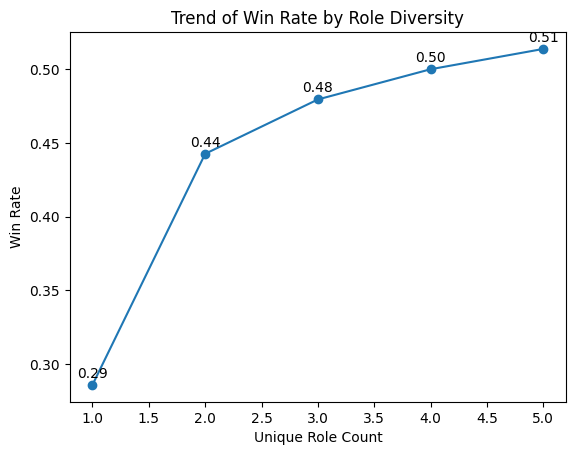

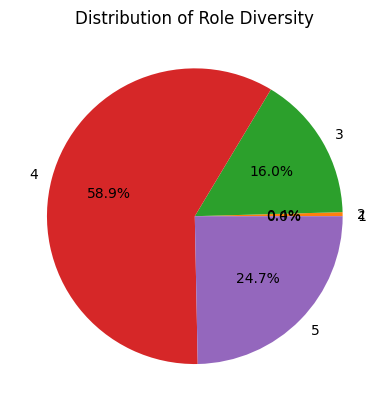

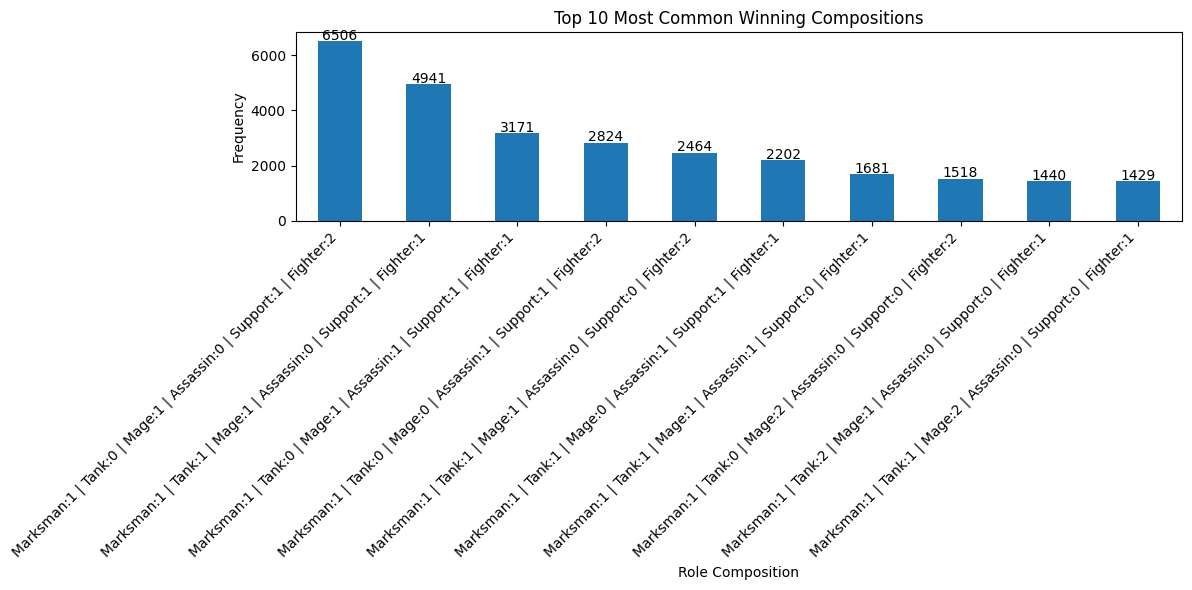

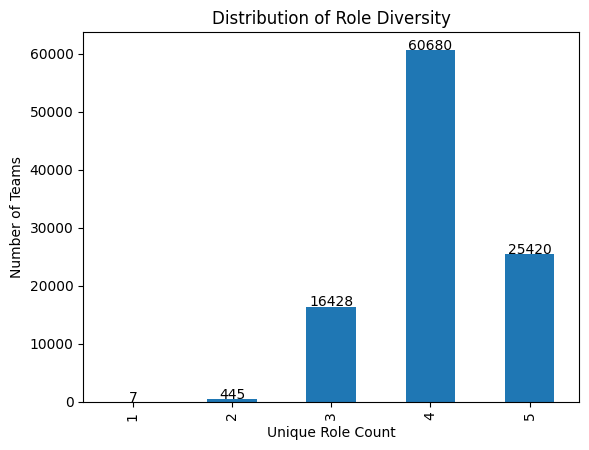

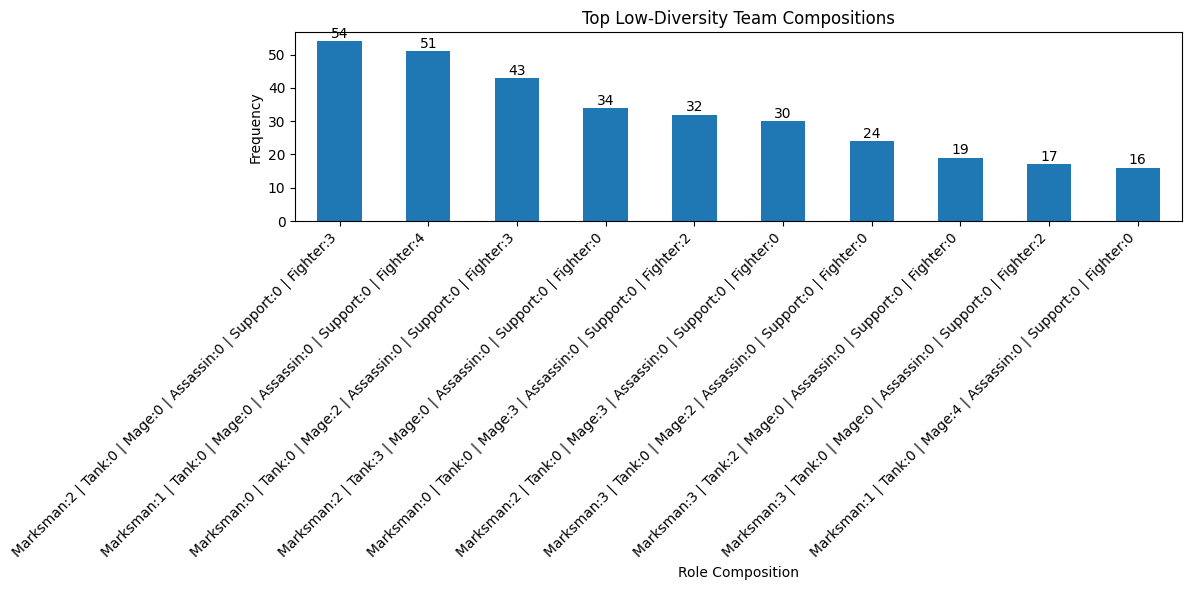

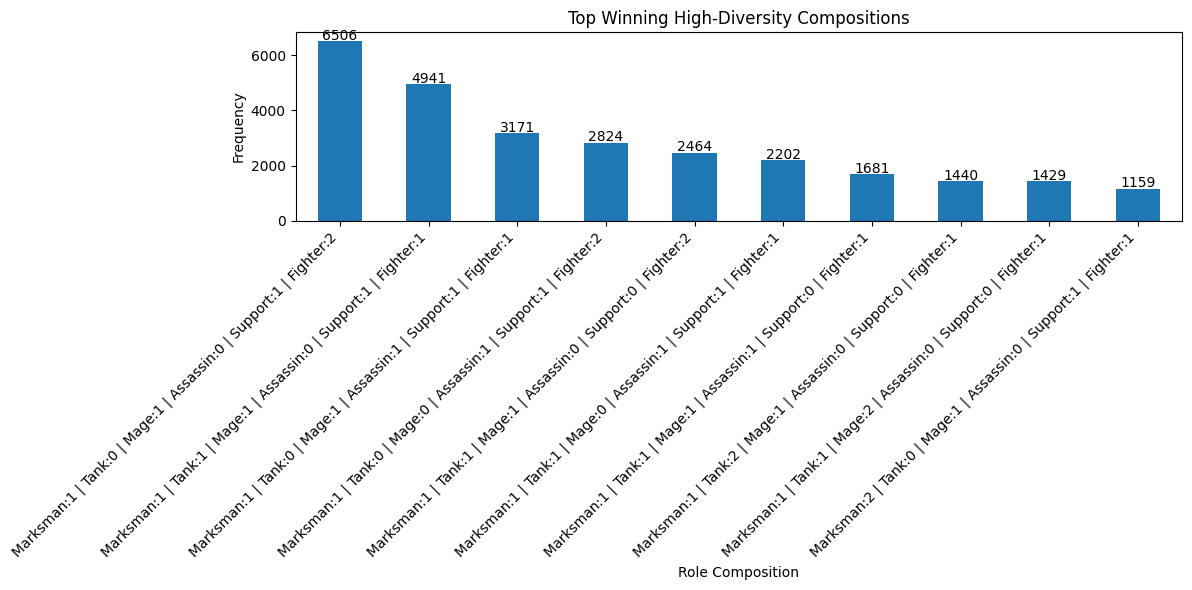

In [ ]:
import pandas as pd
games = pd.read_csv("/content/games.csv", sep=';')
games.head()
games.columns.tolist()

import json

with open("/content/champion_names&roles.json", "r", encoding="utf-8") as f:
    champ_data = json.load(f)

role_map = {}

for champ_name, info in champ_data["data"].items():
    champ_id = int(info["key"])
    primary_role = info["tags"][0]
    role_map[champ_id] = primary_role

list(role_map.items())[:10]

t1_cols = [f"t1_champ{i}id" for i in range(1, 6)]
t2_cols = [f"t2_champ{i}id" for i in range(1, 6)]

def get_role_counts(champion_ids):
    roles = [role_map.get(champ_id, "Unknown") for champ_id in champion_ids]

    counts = {
        "Marksman": roles.count("Marksman"),
        "Tank": roles.count("Tank"),
        "Mage": roles.count("Mage"),
        "Assassin": roles.count("Assassin"),
        "Support": roles.count("Support"),
        "Fighter": roles.count("Fighter"),
        "diversity": len(set(roles))
    }

    return counts

rows = []

for _, row in games.iterrows():
    # Team 1
    t1_ids = row[t1_cols].tolist()
    t1_features = get_role_counts(t1_ids)
    t1_features["win"] = 1 if row["winner"] == 1 else 0
    rows.append(t1_features)

    # Team 2
    t2_ids = row[t2_cols].tolist()
    t2_features = get_role_counts(t2_ids)
    t2_features["win"] = 1 if row["winner"] == 2 else 0
    rows.append(t2_features)

team_df = pd.DataFrame(rows)
team_df.head()

team_df.to_csv("/content/team_role_dataset.csv", index=False)

diversity_winrate = team_df.groupby("diversity")["win"].mean()
diversity_winrate

import matplotlib.pyplot as plt

ax = diversity_winrate.plot(marker="o")
plt.title("Trend of Win Rate by Role Diversity")
plt.xlabel("Unique Role Count")
plt.ylabel("Win Rate")

for x, y in zip(diversity_winrate.index, diversity_winrate.values):
    plt.text(x, y + 0.005, f"{y:.2f}", ha="center")

plt.show()

team_df["diversity"].value_counts().sort_index().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Distribution of Role Diversity")
plt.ylabel("")
plt.show()
"""
diversity_winrate.plot(kind="bar")
plt.title("Win Rate by Role Diversity")
plt.xlabel("Number of Unique Roles")
plt.ylabel("Win Rate")
plt.show()

support_winrate = team_df.groupby(team_df["Support"] > 0)["win"].mean()
support_winrate

support_winrate.plot(kind="bar")
plt.title("Win Rate: Support vs No Support")
plt.xlabel("Has Support")
plt.ylabel("Win Rate")
plt.show()

winning_avg_roles = team_df[team_df["win"] == 1][
    ["Marksman", "Tank", "Mage", "Assassin", "Support", "Fighter"]
].mean()

winning_avg_roles

winning_avg_roles.plot(kind="bar")
plt.title("Average Role Counts in Winning Teams")
plt.xlabel("Role")
plt.ylabel("Average Count")
plt.show()

double_marksman = team_df.groupby(team_df["Marksman"] >= 2)["win"].mean()
double_marksman

ax = double_marksman.plot(kind="bar")
plt.title("Win Rate: Double Marksman vs Others")
plt.xlabel("Has Double Marksman")
plt.ylabel("Win Rate")

for i, v in enumerate(double_marksman):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()

assassin_groups = team_df.copy()

assassin_groups["Assassin Group"] = assassin_groups["Assassin"].apply(
    lambda x: "0" if x == 0 else ("1" if x == 1 else "2+")
)

assassin_winrate = assassin_groups.groupby("Assassin Group")["win"].mean()
assassin_winrate

ax = assassin_winrate.plot(kind="bar")
plt.title("Win Rate by Number of Assassins")
plt.xlabel("Assassin Count")
plt.ylabel("Win Rate")

for i, v in enumerate(assassin_winrate):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()


synergy_df = team_df[team_df["Marksman"] >= 1].copy()

synergy_df["ADC Support Setup"] = synergy_df["Support"].apply(
    lambda x: "Marksman + Support" if x >= 1 else "Marksman without Support"
)

adc_support_winrate = synergy_df.groupby("ADC Support Setup")["win"].mean()
adc_support_winrate

ax = adc_support_winrate.plot(kind="bar")
plt.title("Win Rate: Marksman With vs Without Support")
plt.xlabel("Composition Type")
plt.ylabel("Win Rate")

for i, v in enumerate(adc_support_winrate):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()


tank_groups = team_df.copy()

tank_groups["Tank Group"] = tank_groups["Tank"].apply(
    lambda x: "0" if x == 0 else ("1" if x == 1 else "2+")
)

tank_winrate = tank_groups.groupby("Tank Group")["win"].mean()
tank_winrate

ax = tank_winrate.plot(kind="bar")
plt.title("Win Rate by Number of Tanks")
plt.xlabel("Tank Count")
plt.ylabel("Win Rate")

for i, v in enumerate(tank_winrate):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()
"""



winning_comps = (
    team_df[team_df["win"] == 1]
    .groupby(["Marksman", "Tank", "Mage", "Assassin", "Support", "Fighter"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

winning_comps

formatted_labels = [
    f"Marksman:{idx[0]} | Tank:{idx[1]} | Mage:{idx[2]} | "
    f"Assassin:{idx[3]} | Support:{idx[4]} | Fighter:{idx[5]}"
    for idx in winning_comps.index
]

ax = winning_comps.plot(kind="bar", figsize=(12, 6))
plt.title("Top 10 Most Common Winning Compositions")
plt.xlabel("Role Composition")
plt.ylabel("Frequency")

ax.set_xticklabels(formatted_labels, rotation=45, ha="right")

for i, v in enumerate(winning_comps):
    ax.text(i, v + 50, str(v), ha="center")

plt.tight_layout()
plt.show()

diversity_distribution = team_df["diversity"].value_counts().sort_index()
diversity_distribution

ax = diversity_distribution.plot(kind="bar")
plt.title("Distribution of Role Diversity")
plt.xlabel("Unique Role Count")
plt.ylabel("Number of Teams")

for i, v in enumerate(diversity_distribution):
    ax.text(i, v + 50, str(v), ha="center")

plt.show()

low_div_comps = (
    team_df[team_df["diversity"] <= 2]
    .groupby(["Marksman", "Tank", "Mage", "Assassin", "Support", "Fighter"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

low_div_comps

low_div_labels = [
    f"Marksman:{idx[0]} | Tank:{idx[1]} | Mage:{idx[2]} | "
    f"Assassin:{idx[3]} | Support:{idx[4]} | Fighter:{idx[5]}"
    for idx in low_div_comps.index
]

ax = low_div_comps.plot(kind="bar", figsize=(12, 6))
plt.title("Top Low-Diversity Team Compositions")
plt.xlabel("Role Composition")
plt.ylabel("Frequency")

ax.set_xticklabels(low_div_labels, rotation=45, ha="right")

for i, v in enumerate(low_div_comps):
    ax.text(i, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()

high_div_wins = (
    team_df[(team_df["diversity"] >= 4) & (team_df["win"] == 1)]
    .groupby(["Marksman", "Tank", "Mage", "Assassin", "Support", "Fighter"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

high_div_wins

high_div_labels = [
    f"Marksman:{idx[0]} | Tank:{idx[1]} | Mage:{idx[2]} | "
    f"Assassin:{idx[3]} | Support:{idx[4]} | Fighter:{idx[5]}"
    for idx in high_div_wins.index
]

ax = high_div_wins.plot(kind="bar", figsize=(12, 6))
plt.title("Top Winning High-Diversity Compositions")
plt.xlabel("Role Composition")
plt.ylabel("Frequency")

ax.set_xticklabels(high_div_labels, rotation=45, ha="right")

for i, v in enumerate(high_div_wins):
    ax.text(i, v + 50, str(v), ha="center")

plt.tight_layout()
plt.show()



In [12]:
import pandas as pd
team_df = pd.read_csv("/content/team_role_dataset.csv", sep=";")
team_df.head()

,Marksman,Tank,Mage,Assassin,Support,Fighter,diversity,win
0,1,0,2,1,1,0,4,1
1,2,0,0,1,1,1,4,0
2,1,0,0,2,0,2,3,1
3,0,1,1,0,0,3,3,0
4,1,0,0,1,1,2,4,1


### Hypotheses
- **H0:** Role diversity and winning are independent.
- **H1:** There is a statistically significant relationship between role diversity and winning.

In [13]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(team_df["diversity"], team_df["win"])

print("Contingency Table:")
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Contingency Table:
win            0      1
diversity              
1              5      2
2            248    197
3           8549   7879
4          30332  30348
5          12356  13064

Chi-square statistic: 54.179451390686104
p-value: 4.826464458492728e-11
Degrees of freedom: 4


### Interpretation
The chi-square test returned a p-value of 4.83e-11, which is far below the significance threshold of 0.05.

Therefore, the null hypothesis is rejected.

This confirms that team role diversity and match outcomes are statistically dependent, supporting the earlier EDA findings that higher diversity is associated with improved win rates.